In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
x = np.array([[1],[2],[3],[4]])
y = np.array([2,4,6,8])

In [ ]:
class LassoRegression:
    """
    Lasso Regression implemented using Gradient Descent.

    Adds L1 regularization which encourages sparsity
    (some weights become exactly zero).

    Loss Function:
        J = (1/n) * Σ(y - ŷ)^2 + λ * Σ|w|

    Uses subgradient method for L1 term.

    Attributes:
    Same as RidgeRegression
    """

    def __init__(self, x, y, lambda_=0.1):
        """ 
        Constructor to initialize input features and target.

        Parameters:
            x (array-like): Input feature(s), shape (n_samples, n_features).
            y (array-like): Target values, shape (n_samples,).
        
        """
        self.x = np.array(x)
        self.y = np.array(y)
        self.lambda_ = lambda_


    def fit(self, alpha=0.01, num_iteration=1000):
        """
        Trains the lasso regression model using gradient descent.

        Parameters:
            alpha (float): Learning rate for weight updates.
            num_iteration (int): Number of iterations for gradient descent.

        Updates:
            self.w: Trained weight(s).
            self.b: Trained bias.
            self.loss_history: Records loss at each iteration for visualization.

        """
        n_samples, n_features = self.x.shape

        self.w = np.zeros(n_features)
        self.b = 0
        self.alpha = alpha
        self.num_iteration = num_iteration
        self.loss_history = []

        for _ in range(self.num_iteration):
            y_hat = np.dot(self.x, self.w) + self.b

            dw = (2/n_samples) * np.dot(self.x.T, (y_hat - self.y)) + self.lambda_ * np.sign(self.w)
            db = (2/n_samples) * np.sum(y_hat - self.y)

            self.w -= self.alpha * dw
            self.b -= self.alpha * db

            loss = (1/n_samples) * np.sum((self.y - y_hat)**2) + self.lambda_ * np.sum(np.abs(self.w))

            self.loss_history.append(loss)


    def predict(self, x_new):
        """
        Makes predictions using the trained model.

        Parameters:
            x_new (array-like): New input feature(s), shape (n_samples, n_features).

        Returns:
            ndarray: Predicted values for the input data.
        """
        x_new = np.array(x_new)
        return np.dot(x_new, self.w) + self.b

    def calc_MSE(self):
        """
        Calculates Mean Squared Error (MSE) of the model on training data.

        Returns:
            float: Mean Squared Error.
        """
        y_hat = self.w * self.x + self.b
        mse = np.mean((self.y - y_hat) ** 2)
        return mse

    def calc_RMSE(self):
        """
        Calculates Root Mean Squared Error (RMSE) of the model on training data.

        Returns:
        float: Root Mean Squared Error.
        """
        return np.sqrt(self.calc_MSE())

    def calc_R2Score(self):
        """
        Calculates the R-squared (coefficient of determination) of the model.

        Returns:
        float: R² score, indicates how well the model explains variance in y.
        """
        y_hat = self.w * self.x + self.b
        sse = np.sum((self.y - y_hat) ** 2)
        sst = np.sum((self.y - np.mean(self.y)) ** 2)
        r2  = 1 - (sse / sst)
        return r2


    def visualize(self):    
        """
        Visualizes training results.

        Plots:
            1. SSE (Sum of Squared Errors) over iterations.
            2. Regression line along with original data points.
        """
        plt.figure(figsize=(12,4))
        plt.subplot(1,2,1)
        plt.plot(range(self.num_iteration) , self.loss_history, label='loss')
        plt.xlabel("Iteration")
        plt.ylabel("Loss")
        plt.title("Loss over Iteration")
        plt.legend()
        plt.subplot(1,2,2)
        plt.scatter(self.x,self.y,color="blue",label="Data point")
        plt.plot(self.x,self.w*self.x+self.b,color="red" , label="Lasso line")
        plt.xlabel("X")
        plt.ylabel("Y")
        plt.title("Lasso Regression fit line")
        plt.show()

In [16]:
l3=LassoRegression(x,y,10)
l3.fit(0.0100,1000)

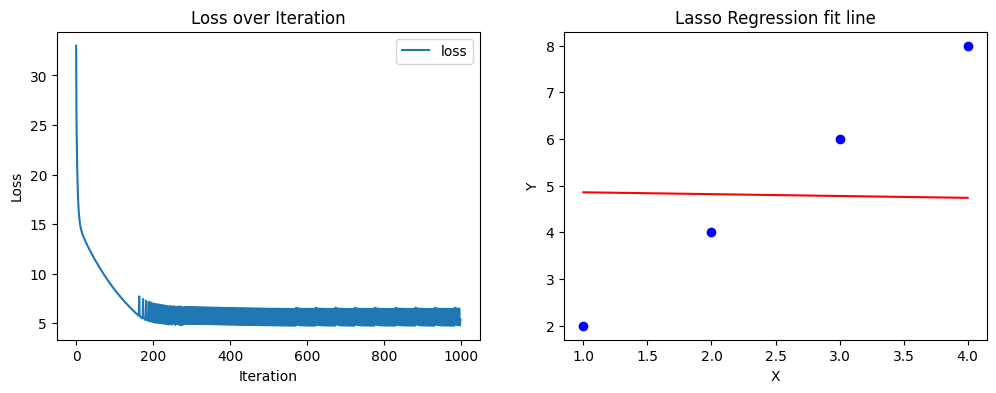

In [17]:
l3.visualize()

In [18]:
print(l3.predict(2))
print(l3.predict(3))
print(l3.calc_MSE())
print(l3.calc_RMSE())
print(l3.calc_R2Score())

[4.81962907]
[4.7798977]
5.042067928338277
2.245454949077865
-3.033654342670621


In [ ]:
# class LassoRegression:
#     """
#     LassoRegression class implements Lasso  regression using gradient descent.

#     Attributes:
#     X (array-like): Input features (1D or 2D).
#     y (array-like): Target values.
#     w (float or ndarray): Weight(s) for features.
#     b (float): Bias term.
#     alpha (float): Learning rate for gradient descent.
#     num_iteration (int): Number of iterations for training.
#     sse_value (list): Sum of squared errors for each iteration.
#     """
#     def __init__(self,x,y,lambda_):
#         """ 
#         Constructor to initialize input features and target.

#         Parameters:
#         x (array-like): Input feature(s), shape (n_samples,) or (n_samples, n_features).
#         y (array-like): Target values, shape (n_samples,).
        
#         """
#         self.x=np.array(x)
#         self.y=np.array(y)
#         self.lambda_=lambda_


#     def fit(self,alpha,num_iteration):
#         """
#         Trains the lasso regression model using gradient descent.

#         Parameters:
#         alpha (float): Learning rate for weight updates.
#         num_iteration (int): Number of iterations for gradient descent.

#         Updates:
#         self.w: Trained weight(s).
#         self.b: Trained bias.
#         self.sse_value: Records SSE at each iteration for visualization.

#         """
#         self.w = 0
#         self.b = 0
#         self.alpha = alpha
#         self.num_iteration= num_iteration
#         n = len(self.x)
#         self.sse_value= []
#         for i in range(self.num_iteration):
#             y_hat = self.w* self.x + self.b

#             D_w = (2/n) * np.sum((y_hat-self.y)*self.x)
#             D_b = (2/n) * np.sum(y_hat-self.y)
            
#             # L1 gradient
#             D_w += (self.lambda_/n) * np.sign(self.w)

#             self.w -=  self.alpha * D_w
#             self.b -=  self.alpha * D_b
            
#             sse = (np.sum((y_hat-self.y)**2)) + self.lambda_ * np.abs(self.w)
#             self.sse_value.append(sse)


#     def predict(self,new_x):
#         """
#         Makes predictions using the trained model.

#         Parameters:
#         new_x (array-like): New input data for prediction.

#         Returns:
#         ndarray: Predicted values for the input data.
#         """
#         new_x=np.array(new_x)
#         return self.w * new_x + self.b


#     def visualize(self):    
#         """
#             Visualizes training results.

#             Plots:
#             1. SSE (Sum of Squared Errors) over iterations.
#             2. Regression line along with original data points.
#             """
#         plt.figure(figsize=(12,4))
#         plt.subplot(1,2,1)
#         plt.plot(range(self.num_iteration) , self.sse_value, label='sse')
#         plt.xlabel("Iteration")
#         plt.ylabel("SSE")
#         plt.title("SSE over Iteration")
#         plt.legend()
#         plt.subplot(1,2,2)
#         plt.scatter(self.x,self.y,color="blue",label="Data point")
#         plt.plot(self.x,self.w*self.x+self.b,color="red" , label="Lasso line")
#         plt.xlabel("X")
#         plt.ylabel("Y")
#         plt.title("Lasso Regression fit line")
#         plt.show()


#     def calc_MSE(self):
#         """
#         Calculates Mean Squared Error (MSE) of the model on training data.

#         Returns:
#         float: Mean Squared Error.
#         """
#         y_hat = self.w * self.x + self.b
#         mse = np.mean((self.y - y_hat) ** 2)
#         return mse

#     def calc_RMSE(self):
#         """
#         Calculates Root Mean Squared Error (RMSE) of the model on training data.

#         Returns:
#         float: Root Mean Squared Error.
#         """
#         return np.sqrt(self.calc_MSE())

#     def calc_R2Score(self):
#         """
#         Calculates the R-squared (coefficient of determination) of the model.

#         Returns:
#         float: R² score, indicates how well the model explains variance in y.
#         """
#         y_hat = self.w * self.x + self.b
#         sse = np.sum((self.y - y_hat) ** 2)
#         sst = np.sum((self.y - np.mean(self.y)) ** 2)
#         r2  = 1 - (sse / sst)
#         return r2
